In [1]:
# ============================================
# SpectraGuard - RF Modulation Classification
# Cell 1: Imports and Device Setup
# ============================================

import os, time, random, csv, gc
import h5py
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

print("PyTorch version:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
GPU count: 2


In [2]:
# ============================================
# Cell 2: Dataset Configuration
# ============================================

DATA_PATH = "/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5"

CLASS_NAMES = [
    'OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK',
    '16APSK', '32APSK', '64APSK', '128APSK',
    '16QAM', '32QAM', '64QAM', '128QAM', '256QAM',
    'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC',
    'FM', 'GMSK', 'OQPSK'
]
NUM_CLASSES = len(CLASS_NAMES)

# All SNR levels in dataset
SNR_LEVELS_ALL = list(range(-20, 32, 2))

# REALISTIC: Only use SNR >= 5 dB (where signals are actually decodable)
SNR_THRESHOLD = 5
SNR_LEVELS = [s for s in SNR_LEVELS_ALL if s >= SNR_THRESHOLD]

SAMPLES_PER_CLASS_PER_SNR = 1000
BATCH_SIZE = 256

print("="*70)
print("REALISTIC DATASET CONFIGURATION")
print("="*70)
print(f"Dataset: {DATA_PATH}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"SNR threshold: {SNR_THRESHOLD} dB (realistic range)")
print(f"SNR levels used: {SNR_LEVELS}")
print(f"SNR range: {SNR_LEVELS[0]} to {SNR_LEVELS[-1]} dB")
print(f"Samples per class/SNR: {SAMPLES_PER_CLASS_PER_SNR}")
print(f"Batch size: {BATCH_SIZE}")
print("\nNote: Excluding SNR < 5 dB (physically undecodable signals)")
print("="*70)

REALISTIC DATASET CONFIGURATION
Dataset: /kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
Number of classes: 24
SNR threshold: 5 dB (realistic range)
SNR levels used: [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
SNR range: 6 to 30 dB
Samples per class/SNR: 1000
Batch size: 256

Note: Excluding SNR < 5 dB (physically undecodable signals)


In [3]:
# ============================================
# Cell 3: Load RF/IQ Dataset (Realistic SNR Only)
# ============================================

print("\n" + "="*70)
print("LOADING DATASET")
print("="*70 + "\n")

X_list, y_list, snr_list = [], [], []

with h5py.File(DATA_PATH, "r") as f:
    X = f["X"]
    Y_all = f["Y"][:].argmax(axis=1)
    Z_all = f["Z"][:, 0]
    print(f"Total data in file: {X.shape}")

    for snr in SNR_LEVELS:
        print(f"Loading SNR = {snr:>3} dB", end='\r')

        snr_indices = np.where(Z_all == snr)[0]
        snr_labels = Y_all[snr_indices]

        for class_idx in range(NUM_CLASSES):
            sel = snr_indices[snr_labels == class_idx][:SAMPLES_PER_CLASS_PER_SNR]

            if len(sel) == 0:
                continue

            if sel[-1] - sel[0] + 1 == len(sel):
                chunk = X[sel[0]:sel[-1] + 1]
            else:
                chunk = X[sel]

            X_list.append(chunk.transpose(0, 2, 1))
            y_list.append(np.full(len(sel), class_idx, dtype=np.int64))
            snr_list.append(np.full(len(sel), snr, dtype=np.int64))

X_pilot   = np.concatenate(X_list, axis=0).astype(np.float32)
y_pilot   = np.concatenate(y_list)
snr_pilot = np.concatenate(snr_list)
del X_list, y_list, snr_list, Y_all, Z_all
gc.collect()

print("\n" + "="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)
print(f"X shape   : {X_pilot.shape} (N, channels, length)")
print(f"y shape   : {y_pilot.shape}")
print(f"SNR shape : {snr_pilot.shape}")
print(f"Memory    : {round(X_pilot.nbytes / (1024**2), 2)} MB")
print(f"SNR range : {snr_pilot.min()} to {snr_pilot.max()} dB")
print("="*70)


LOADING DATASET

Total data in file: (2555904, 1024, 2)
Loading SNR =  30 dB
DATASET LOADED SUCCESSFULLY
X shape   : (312000, 2, 1024) (N, channels, length)
y shape   : (312000,)
SNR shape : (312000,)
Memory    : 2437.5 MB
SNR range : 6 to 30 dB



DATASET VERIFICATION

Total samples: 312,000
Number of classes: 24

Class distribution:
   0 - OOK         : 13,000
   1 - 4ASK        : 13,000
   2 - 8ASK        : 13,000
   3 - BPSK        : 13,000
   4 - QPSK        : 13,000
   5 - 8PSK        : 13,000
   6 - 16PSK       : 13,000
   7 - 32PSK       : 13,000
   8 - 16APSK      : 13,000
   9 - 32APSK      : 13,000
  10 - 64APSK      : 13,000
  11 - 128APSK     : 13,000
  12 - 16QAM       : 13,000
  13 - 32QAM       : 13,000
  14 - 64QAM       : 13,000
  15 - 128QAM      : 13,000
  16 - 256QAM      : 13,000
  17 - AM-SSB-WC   : 13,000
  18 - AM-SSB-SC   : 13,000
  19 - AM-DSB-WC   : 13,000
  20 - AM-DSB-SC   : 13,000
  21 - FM          : 13,000
  22 - GMSK        : 13,000
  23 - OQPSK       : 13,000

SNR distribution:
    6 dB : 24,000
    8 dB : 24,000
   10 dB : 24,000
   12 dB : 24,000
   14 dB : 24,000
   16 dB : 24,000
   18 dB : 24,000
   20 dB : 24,000
   22 dB : 24,000
   24 dB : 24,000
   26 dB : 24,000
   28 dB : 24,000
   3

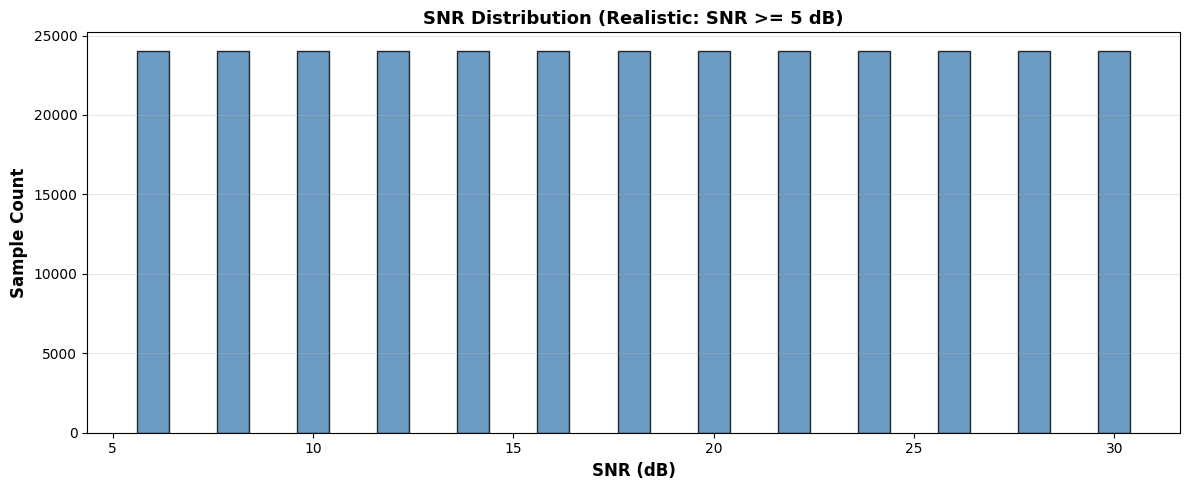


✓ SNR distribution saved!


In [4]:
# ============================================
# Cell 4: Dataset Verification
# ============================================

print("\n" + "="*70)
print("DATASET VERIFICATION")
print("="*70 + "\n")

print(f"Total samples: {len(X_pilot):,}")
print(f"Number of classes: {NUM_CLASSES}")

# Class distribution
unique_classes, class_counts = np.unique(y_pilot, return_counts=True)
print(f"\nClass distribution:")
for cls, count in zip(unique_classes, class_counts):
    print(f"  {cls:2d} - {CLASS_NAMES[cls]:12s}: {count:,}")

# SNR distribution
unique_snr, snr_counts = np.unique(snr_pilot, return_counts=True)
print(f"\nSNR distribution:")
for s, count in zip(unique_snr, snr_counts):
    print(f"  {s:3d} dB : {count:,}")

# Sample statistics
print(f"\nSample statistics:")
print(f"  Minimum : {X_pilot.min():.4f}")
print(f"  Maximum : {X_pilot.max():.4f}")
print(f"  Mean    : {X_pilot.mean():.4f}")
print(f"  Std     : {X_pilot.std():.4f}")

# SNR Distribution Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(unique_snr, snr_counts, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xlabel('SNR (dB)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
ax.set_title(f'SNR Distribution (Realistic: SNR >= {SNR_THRESHOLD} dB)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('snr_distribution_realistic.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ SNR distribution saved!")

In [5]:
# ============================================
# Cell 5: Train/Val/Test Split
# ============================================

print("\n" + "="*70)
print("DATA SPLITTING")
print("="*70 + "\n")

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X_pilot, y_pilot, snr_pilot, test_size=0.30, random_state=42, stratify=y_pilot
)

X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set   : {len(X_train):,} samples ({len(X_train)/len(X_pilot)*100:.1f}%)")
print(f"Validation set : {len(X_val):,} samples ({len(X_val)/len(X_pilot)*100:.1f}%)")
print(f"Test set       : {len(X_test):,} samples ({len(X_test)/len(X_pilot)*100:.1f}%)")
print(f"Total          : {len(X_pilot):,} samples")

# Verify class balance
print(f"\nClass balance check:")
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    min_count = counts.min()
    max_count = counts.max()
    ratio = max_count / min_count
    status = "✓ Balanced" if ratio < 1.1 else "✗ Imbalanced"
    print(f"  {split_name}: Min={min_count:,}, Max={max_count:,}, Ratio={ratio:.2f} {status}")

print("\n" + "="*70)


DATA SPLITTING

Training set   : 218,400 samples (70.0%)
Validation set : 46,800 samples (15.0%)
Test set       : 46,800 samples (15.0%)
Total          : 312,000 samples

Class balance check:
  Train: Min=9,100, Max=9,100, Ratio=1.00 ✓ Balanced
  Val: Min=1,950, Max=1,950, Ratio=1.00 ✓ Balanced
  Test: Min=1,950, Max=1,950, Ratio=1.00 ✓ Balanced



In [6]:
# ============================================
# Cell 6: Create DataLoaders
# ============================================

print("\nCreating dataloaders...")

train_dataset = TensorDataset(torch.from_numpy(X_train).float(), 
                              torch.from_numpy(y_train).long())
val_dataset = TensorDataset(torch.from_numpy(X_val).float(), 
                            torch.from_numpy(y_val).long())
test_dataset = TensorDataset(torch.from_numpy(X_test).float(), 
                             torch.from_numpy(y_test).long())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

dataset_sizes = {
    'train': len(train_dataset),
    'val': len(val_dataset),
    'test': len(test_dataset)
}

print(f"✓ DataLoaders created with batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


Creating dataloaders...
✓ DataLoaders created with batch size: 256
  Train batches: 854
  Val batches:   183
  Test batches:  183


In [7]:
# ============================================
# Cell 7: CNN Model Definition
# ============================================

class CNN(nn.Module):
    """CNN for 1D RF signal classification"""
    def __init__(self, num_classes=24):
        super(CNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

print("CNN model defined successfully")

CNN model defined successfully


In [8]:
# ============================================
# Cell 8: ResNet Model Definition
# ============================================

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.stride = stride
        
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()
    
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity
        out = self.relu(out)
        return out

class ResNet1D(nn.Module):
    def __init__(self, num_classes=24):
        super(ResNet1D, self).__init__()
        self.conv1 = nn.Conv1d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, 64, 3, stride=1)
        self.layer2 = self._make_layer(64, 128, 4, stride=2)
        self.layer3 = self._make_layer(128, 256, 6, stride=2)
        self.layer4 = self._make_layer(256, 512, 3, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        layers.append(ResidualBlock1D(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels, 1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

print("ResNet model defined successfully")

ResNet model defined successfully


In [9]:
# ============================================
# Cell 9: SpectraNet Model Definition
# ============================================

class TransformerEncoder(nn.Module):
    def __init__(self, d_model, nhead, num_layers, dim_feedforward, dropout=0.1):
        super(TransformerEncoder, self).__init__()
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
    def forward(self, x):
        return self.transformer_encoder(x)

class SpectraNet(nn.Module):
    """CNN + Transformer for RF signal classification"""
    def __init__(self, num_classes=24):
        super(SpectraNet, self).__init__()
        
        # CNN Feature Extraction
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Conv1d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True)
        )
        
        self.d_model = 128
        self.proj = nn.Linear(128, self.d_model)
        
        self.transformer = TransformerEncoder(
            d_model=self.d_model,
            nhead=4,
            num_layers=3,
            dim_feedforward=256,
            dropout=0.1
        )
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        
        x = x.transpose(1, 2)
        x = self.proj(x)
        x = self.transformer(x)
        
        x = x.transpose(1, 2)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        
        return x

print("SpectraNet model defined successfully")

SpectraNet model defined successfully


In [10]:
# ============================================
# Cell 10: Training Function
# ============================================

def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=50):
    """Train a single model"""
    since = time.time()
    best_model_wts = None
    best_loss = float('inf')
    
    history = []
    patience = 10
    patience_counter = 0
    
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}\n")
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_preds, train_labels = [], []
        
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
            
            if (batch_idx + 1) % 30 == 0:
                print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}", end='\r')
        
        train_loss = train_loss / len(train_dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())
        
        val_loss = val_loss / len(val_dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        
        scheduler.step()
        
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        
        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, f'best_{model_name.lower()}_model.pth')
            print(f"  ✓ Best model saved!")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n  Early stopping at epoch {epoch+1}")
                break
    
    time_elapsed = time.time() - since
    print(f"\nTraining completed in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    
    return model, history

print("Training function defined")

Training function defined


In [11]:
# ============================================
# Cell 10: Training Function
# ============================================

def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=50):
    """Train a single model"""
    since = time.time()
    best_model_wts = None
    best_loss = float('inf')
    
    history = []
    patience = 10
    patience_counter = 0
    
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}\n")
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_preds, train_labels = [], []
        
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
            
            if (batch_idx + 1) % 30 == 0:
                print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}", end='\r')
        
        train_loss = train_loss / len(train_dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())
        
        val_loss = val_loss / len(val_dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        
        scheduler.step()
        
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        
        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, f'best_{model_name.lower()}_model.pth')
            print(f"  ✓ Best model saved!")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n  Early stopping at epoch {epoch+1}")
                break
    
    time_elapsed = time.time() - since
    print(f"\nTraining completed in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    
    return model, history

print("Training function defined")

Training function defined


In [12]:
# ============================================
# Cell 11: Train CNN, ResNet, SpectraNet
# ============================================

import copy

# Create models
print("Creating all models...")
cnn = CNN(num_classes=NUM_CLASSES).to(device)
resnet = ResNet1D(num_classes=NUM_CLASSES).to(device)
spectranet = SpectraNet(num_classes=NUM_CLASSES).to(device)

print(f"CNN parameters:        {sum(p.numel() for p in cnn.parameters()):,}")
print(f"ResNet parameters:     {sum(p.numel() for p in resnet.parameters()):,}")
print(f"SpectraNet parameters: {sum(p.numel() for p in spectranet.parameters()):,}\n")

# Setup optimizers
models = {
    'CNN': cnn,
    'ResNet': resnet,
    'SpectraNet': spectranet
}

optimizers = {
    'CNN': optim.AdamW(cnn.parameters(), lr=0.001, weight_decay=1e-4),
    'ResNet': optim.AdamW(resnet.parameters(), lr=0.001, weight_decay=1e-4),
    'SpectraNet': optim.AdamW(spectranet.parameters(), lr=0.0005, weight_decay=1e-4)
}

schedulers = {
    'CNN': lr_scheduler.CosineAnnealingLR(optimizers['CNN'], T_max=50),
    'ResNet': lr_scheduler.CosineAnnealingLR(optimizers['ResNet'], T_max=50),
    'SpectraNet': lr_scheduler.CosineAnnealingLR(optimizers['SpectraNet'], T_max=50)
}

criterion = nn.CrossEntropyLoss()

# Train all models
trained_models = {}
all_histories = {}

for model_name, model in models.items():
    trained_model, history = train_model(
        model, model_name, criterion, 
        optimizers[model_name], schedulers[model_name],
        num_epochs=50
    )
    trained_models[model_name] = trained_model
    all_histories[model_name] = history

print("\n✓ All models trained!")

Creating all models...
CNN parameters:        419,992
ResNet parameters:     7,356,184
SpectraNet parameters: 579,288


TRAINING CNN

Epoch 1/50, Batch 840/854
Epoch 1/50
  Train Loss: 1.1487 | Train Acc: 0.5373
  Val Loss:   0.8680 | Val Acc:   0.6250
  ✓ Best model saved!
Epoch 2/50, Batch 840/854
Epoch 2/50
  Train Loss: 0.7335 | Train Acc: 0.6759
  Val Loss:   0.8152 | Val Acc:   0.6596
  ✓ Best model saved!
Epoch 3/50, Batch 840/854
Epoch 3/50
  Train Loss: 0.5947 | Train Acc: 0.7257
  Val Loss:   3.7906 | Val Acc:   0.3940
Epoch 4/50, Batch 840/854
Epoch 4/50
  Train Loss: 0.5265 | Train Acc: 0.7555
  Val Loss:   1.0277 | Val Acc:   0.6916
Epoch 5/50, Batch 840/854
Epoch 5/50
  Train Loss: 0.4507 | Train Acc: 0.7931
  Val Loss:   1.4712 | Val Acc:   0.6201
Epoch 6/50, Batch 840/854
Epoch 6/50
  Train Loss: 0.4019 | Train Acc: 0.8116
  Val Loss:   1.9318 | Val Acc:   0.6041
Epoch 7/50, Batch 840/854
Epoch 7/50
  Train Loss: 0.3753 | Train Acc: 0.8213
  Val Loss:   2.8978 | Val Acc

In [13]:
# ============================================
# Cell 12: Evaluate All Models
# ============================================

def evaluate_model(model, model_name, test_loader):
    """Evaluate model on test set"""
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return acc, prec, rec, f1, all_preds, all_labels

print("\n" + "="*70)
print("TESTING ALL MODELS")
print("="*70 + "\n")

results = {}

for model_name, model in trained_models.items():
    acc, prec, rec, f1, preds, labels = evaluate_model(model, model_name, test_loader)
    results[model_name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'predictions': preds,
        'labels': labels
    }
    
    print(f"{model_name} Test Results:")
    print(f"  Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}\n")

print("="*70)


TESTING ALL MODELS

CNN Test Results:
  Accuracy:  0.6647 (66.47%)
  Precision: 0.6916
  Recall:    0.6647
  F1-Score:  0.6431

ResNet Test Results:
  Accuracy:  0.8999 (89.99%)
  Precision: 0.9088
  Recall:    0.8999
  F1-Score:  0.8982

SpectraNet Test Results:
  Accuracy:  0.8890 (88.90%)
  Precision: 0.8967
  Recall:    0.8890
  F1-Score:  0.8843



In [14]:
# ============================================
# Cell 13: Final Comparison
# ============================================

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70 + "\n")

# Create comparison dataframe
comparison_data = {
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# Find winner
winner_idx = np.argmax(comparison_data['Accuracy'])
winner = comparison_data['Model'][winner_idx]
best_acc = comparison_data['Accuracy'][winner_idx]

print(f"\n{'='*70}")
print(f"🏆 WINNER: {winner} with {best_acc*100:.2f}% accuracy!")
print(f"{'='*70}\n")

# Save to CSV
df_comparison.to_csv('model_comparison_results.csv', index=False)
print("✓ Comparison saved to model_comparison_results.csv")


FINAL MODEL COMPARISON

     Model  Accuracy  Precision   Recall  F1-Score
       CNN  0.664722   0.691578 0.664722  0.643075
    ResNet  0.899893   0.908815 0.899893  0.898240
SpectraNet  0.888974   0.896694 0.888974  0.884294

🏆 WINNER: ResNet with 89.99% accuracy!

✓ Comparison saved to model_comparison_results.csv


/tmp/ipykernel_49/1672753943.py:26: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49/1672753943.py:27: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('final_comparison_all_models.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


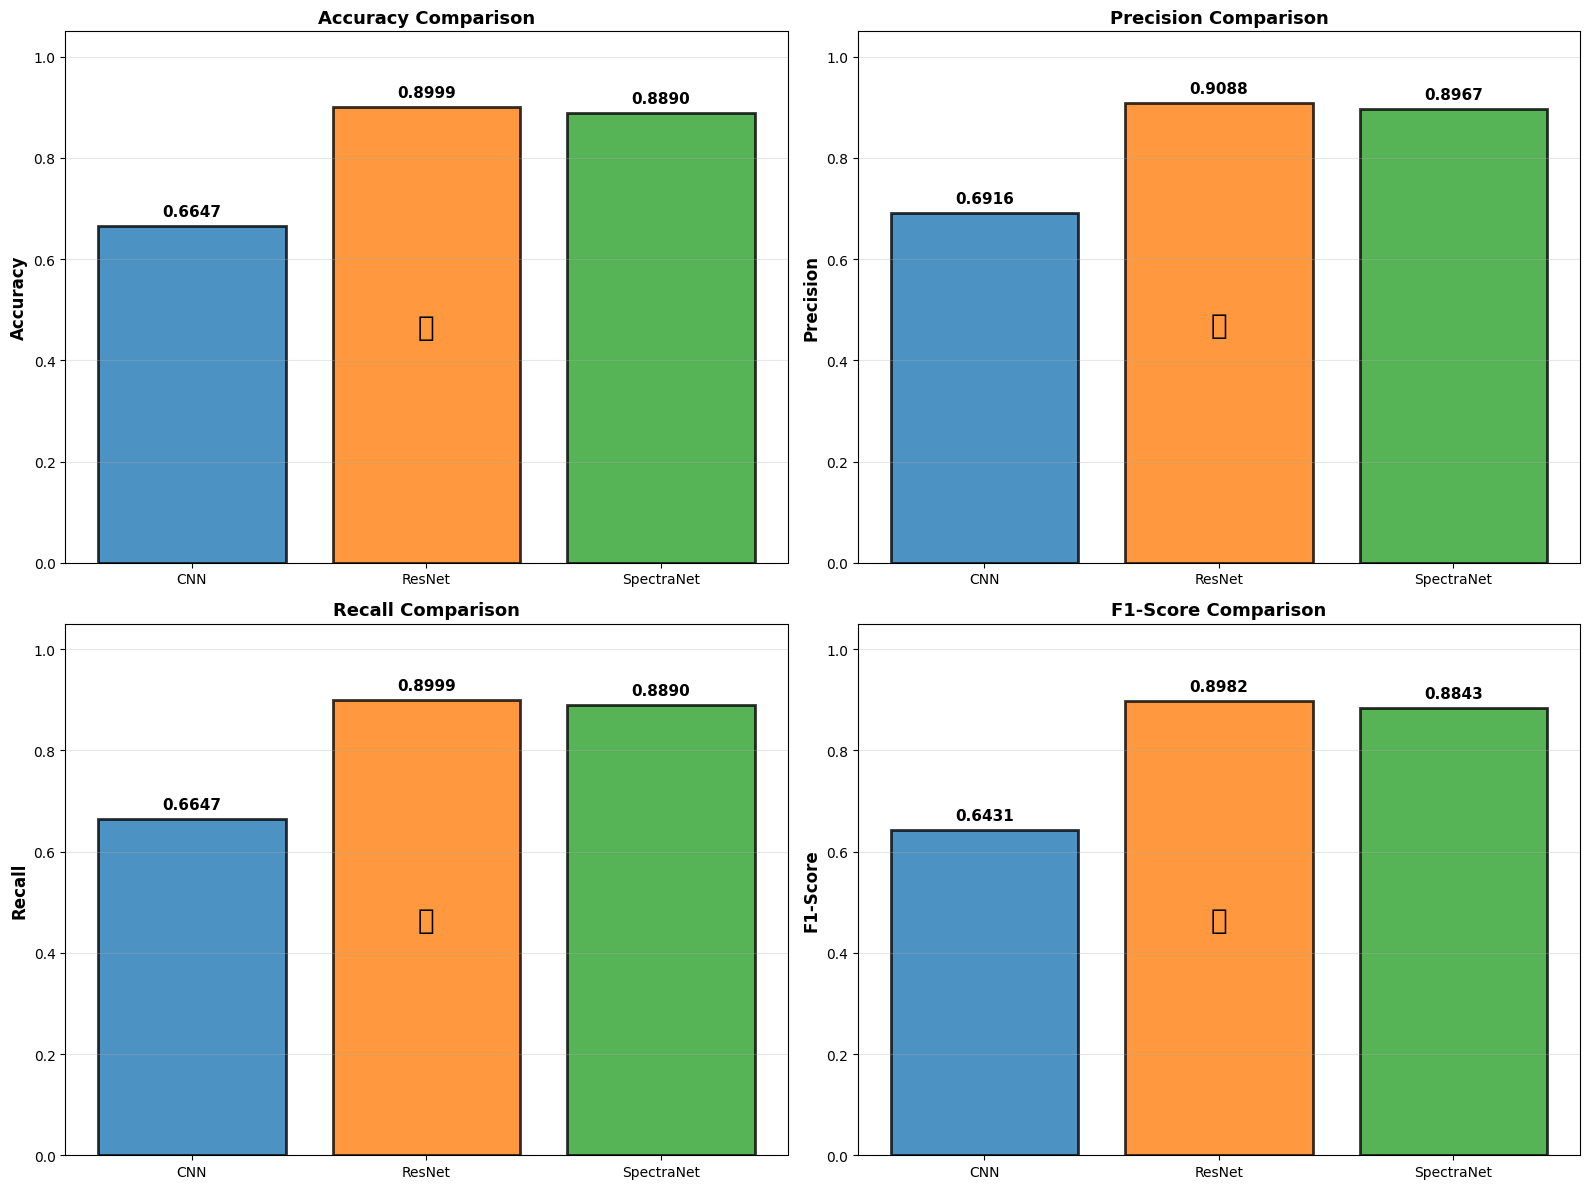

✓ Comparison plot saved!


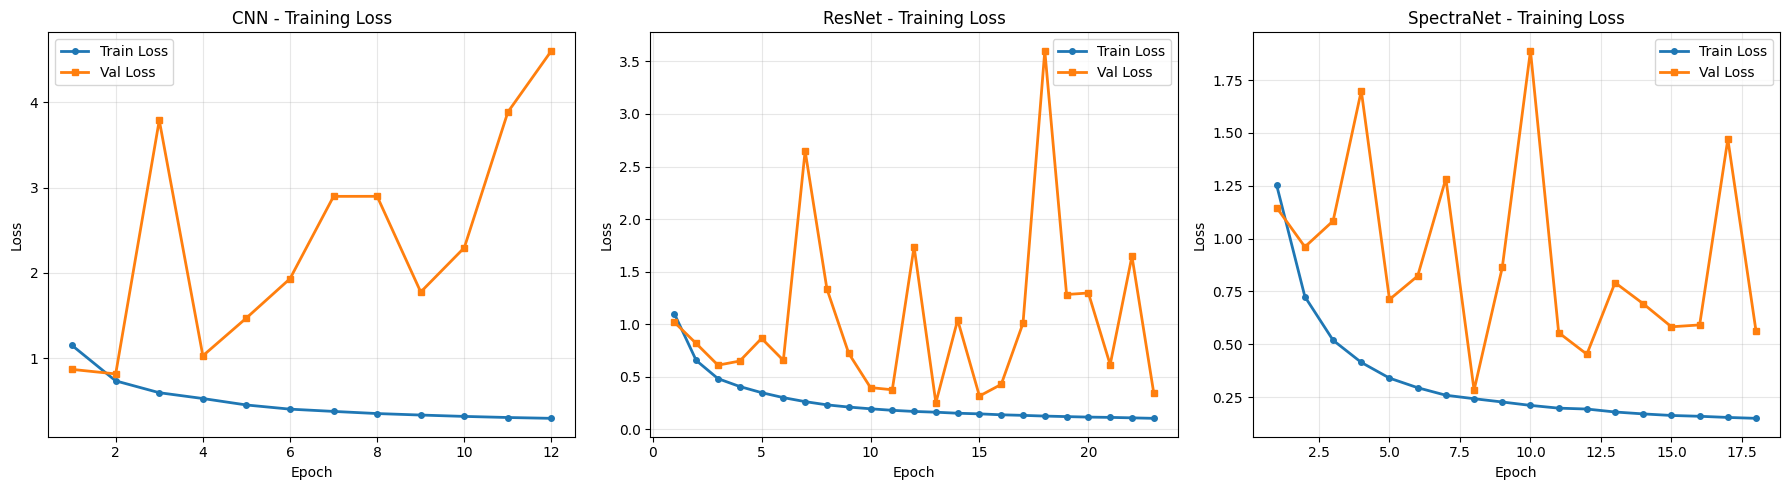

✓ Training history plot saved!


In [15]:
# ============================================
# Cell 14: Visualization & Comparison Plots
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = comparison_data['Model']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, (metric_name, ax) in enumerate(zip(
    ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    axes.flat
)):
    values = comparison_data[metric_name]
    bars = ax.bar(models, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
        if i == winner_idx:
            ax.text(i, v/2, '🏆', ha='center', fontsize=20)

plt.tight_layout()
plt.savefig('final_comparison_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved!")

# Training history plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(models):
    history = all_histories[model_name]
    df_hist = pd.DataFrame(history)
    
    ax = axes[idx]
    ax.plot(df_hist['epoch'], df_hist['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
    ax.plot(df_hist['epoch'], df_hist['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} - Training Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plot saved!")

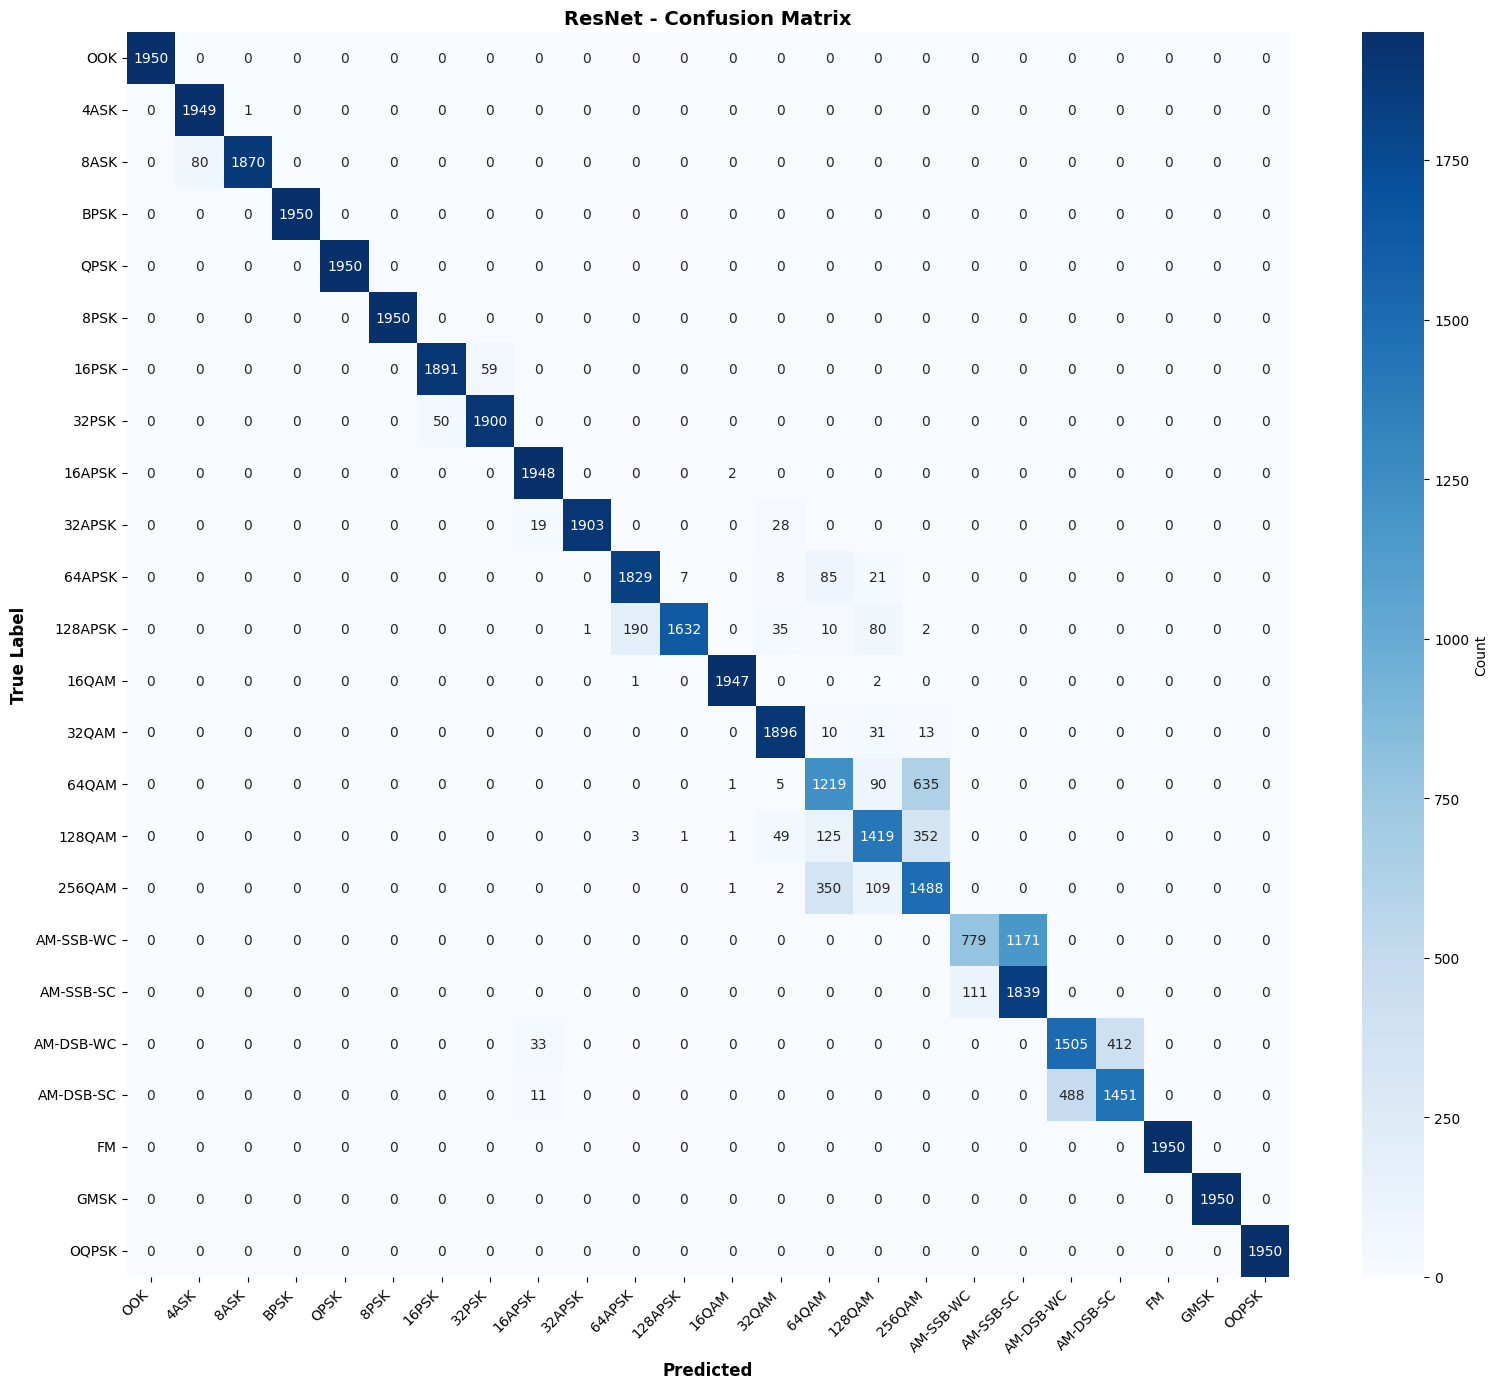


ResNet Classification Report:
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00      1950
        4ASK       0.96      1.00      0.98      1950
        8ASK       1.00      0.96      0.98      1950
        BPSK       1.00      1.00      1.00      1950
        QPSK       1.00      1.00      1.00      1950
        8PSK       1.00      1.00      1.00      1950
       16PSK       0.97      0.97      0.97      1950
       32PSK       0.97      0.97      0.97      1950
      16APSK       0.97      1.00      0.98      1950
      32APSK       1.00      0.98      0.99      1950
      64APSK       0.90      0.94      0.92      1950
     128APSK       1.00      0.84      0.91      1950
       16QAM       1.00      1.00      1.00      1950
       32QAM       0.94      0.97      0.95      1950
       64QAM       0.68      0.63      0.65      1950
      128QAM       0.81      0.73      0.77      1950
      256QAM       0.60      0.76      0.67      1

In [16]:
# ============================================
# Cell 15: Confusion Matrix (Best Model)
# ============================================

from sklearn.metrics import confusion_matrix

# Use best model
best_preds = results[winner]['predictions']
best_labels = results[winner]['labels']

cm = confusion_matrix(best_labels, best_preds)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
            ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'{winner} - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{winner} Classification Report:")
print(classification_report(best_labels, best_preds, target_names=CLASS_NAMES))

print("✓ Confusion matrix and classification report saved!")

In [23]:
# ============================================
# Cell 16: Save Models & Results (FIXED)
# ============================================

print("\n" + "="*70)
print("SAVING MODELS AND RESULTS")
print("="*70 + "\n")

os.makedirs('trained_models', exist_ok=True)

# Save all model weights as .pth
for model_name, model in trained_models.items():
    path = f'trained_models/{model_name.lower()}_realistic.pth'
    torch.save(model.state_dict(), path)
    print(f"✓ {model_name} saved to {path}")

# Save training history
for model_name, history in all_histories.items():
    df_hist = pd.DataFrame(history)
    df_hist.to_csv(f'trained_models/{model_name.lower()}_history.csv', index=False)
    print(f"✓ {model_name} history saved")

# Save comparison results
df_comparison.to_csv('trained_models/model_comparison_detailed.csv', index=False)
print(f"✓ Detailed comparison saved")

# Create per-class metrics from best model
best_preds = results[winner]['predictions']
best_labels = results[winner]['labels']

per_class_metrics = []
for class_idx in range(NUM_CLASSES):
    class_mask = best_labels == class_idx
    if class_mask.sum() == 0:
        continue
    
    class_preds = best_preds[class_mask]
    correct = (class_preds == class_idx).sum()
    total = class_mask.sum()
    class_acc = correct / total
    
    per_class_metrics.append({
        'Class': CLASS_NAMES[class_idx],
        'Accuracy': class_acc,
        'Samples': total
    })

df_per_class = pd.DataFrame(per_class_metrics)
df_per_class.to_csv('trained_models/per_class_metrics.csv', index=False)
print(f"✓ Per-class metrics saved")

# Save summary info as text
summary_info = f"""
TRAINING SUMMARY
================

Dataset Configuration:
  - SNR Threshold: {SNR_THRESHOLD} dB
  - Total Samples: {len(X_pilot):,}
  - Number of Classes: {NUM_CLASSES}
  - Train/Val/Test Split: 70% / 15% / 15%

Models Trained:
  1. CNN - {sum(p.numel() for p in trained_models['CNN'].parameters()):,} parameters
  2. ResNet - {sum(p.numel() for p in trained_models['ResNet'].parameters()):,} parameters
  3. SpectraNet - {sum(p.numel() for p in trained_models['SpectraNet'].parameters()):,} parameters

Results:
  CNN Accuracy: {results['CNN']['accuracy']:.4f} ({results['CNN']['accuracy']*100:.2f}%)
  ResNet Accuracy: {results['ResNet']['accuracy']:.4f} ({results['ResNet']['accuracy']*100:.2f}%)
  SpectraNet Accuracy: {results['SpectraNet']['accuracy']:.4f} ({results['SpectraNet']['accuracy']*100:.2f}%)

Best Model: {winner}
Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)
"""

with open('trained_models/training_summary.txt', 'w') as f:
    f.write(summary_info)

print(f"✓ Training summary saved")

print(f"\n" + "="*70)
print(f"ALL FILES SAVED SUCCESSFULLY")
print(f"="*70)
print(f"\nSaved Files:")
print(f"  ✓ cnn_realistic.pth")
print(f"  ✓ resnet_realistic.pth")
print(f"  ✓ spectranet_realistic.pth")
print(f"  ✓ cnn_history.csv")
print(f"  ✓ resnet_history.csv")
print(f"  ✓ spectranet_history.csv")
print(f"  ✓ model_comparison_detailed.csv")
print(f"  ✓ per_class_metrics.csv")
print(f"  ✓ training_summary.txt")
print(f"\n✓ Ready for deployment!")


SAVING MODELS AND RESULTS

✓ CNN saved to trained_models/cnn_realistic.pth
✓ ResNet saved to trained_models/resnet_realistic.pth
✓ SpectraNet saved to trained_models/spectranet_realistic.pth
✓ CNN history saved
✓ ResNet history saved
✓ SpectraNet history saved
✓ Detailed comparison saved
✓ Per-class metrics saved
✓ Training summary saved

ALL FILES SAVED SUCCESSFULLY

Saved Files:
  ✓ cnn_realistic.pth
  ✓ resnet_realistic.pth
  ✓ spectranet_realistic.pth
  ✓ cnn_history.csv
  ✓ resnet_history.csv
  ✓ spectranet_history.csv
  ✓ model_comparison_detailed.csv
  ✓ per_class_metrics.csv
  ✓ training_summary.txt

✓ Ready for deployment!


In [24]:
# ============================================
# Cell 17: Detailed Model Comparison Table
# ============================================

import json

print("\n" + "="*100)
print("DETAILED MODEL COMPARISON - FINAL RESULTS")
print("="*100 + "\n")

# Create detailed comparison dataframe
detailed_comparison = {
    'Model': [],
    'Test Accuracy': [],
    'Precision (Macro)': [],
    'Recall (Macro)': [],
    'F1-Score (Macro)': [],
    'Parameters': [],
    'Dataset': []
}

for model_name in ['CNN', 'ResNet', 'SpectraNet']:
    detailed_comparison['Model'].append(model_name)
    detailed_comparison['Test Accuracy'].append(results[model_name]['accuracy'])
    detailed_comparison['Precision (Macro)'].append(results[model_name]['precision'])
    detailed_comparison['Recall (Macro)'].append(results[model_name]['recall'])
    detailed_comparison['F1-Score (Macro)'].append(results[model_name]['f1'])
    detailed_comparison['Parameters'].append(sum(p.numel() for p in trained_models[model_name].parameters()))
    detailed_comparison['Dataset'].append(f'RadioML2018 (SNR >= {SNR_THRESHOLD} dB)')

df_detailed = pd.DataFrame(detailed_comparison)

print(df_detailed.to_string(index=False))

print("\n" + "="*100)
print("METRIC DEFINITIONS:")
print("="*100)
print(f"Test Accuracy    : Overall correctness on test set")
print(f"Precision (Macro): Average precision across all 24 modulation classes")
print(f"Recall (Macro)   : Average recall across all 24 modulation classes")
print(f"F1-Score (Macro) : Harmonic mean of precision and recall")
print(f"Parameters       : Total trainable parameters in the model")
print(f"Dataset          : {len(X_pilot):,} samples, {NUM_CLASSES} classes, SNR range {snr_pilot.min()}-{snr_pilot.max()} dB")

# Save detailed comparison
df_detailed.to_csv('model_comparison_detailed.csv', index=False)
print(f"\n✓ Detailed comparison saved to model_comparison_detailed.csv")

# Per-class metrics for best model
print("\n" + "="*100)
print(f"PER-CLASS METRICS - {winner.upper()}")
print("="*100 + "\n")

best_preds = results[winner]['predictions']
best_labels = results[winner]['labels']

per_class_metrics = []
for class_idx in range(NUM_CLASSES):
    class_mask = best_labels == class_idx
    if class_mask.sum() == 0:
        continue
    
    class_preds = best_preds[class_mask]
    correct = (class_preds == class_idx).sum()
    total = class_mask.sum()
    class_acc = correct / total
    
    per_class_metrics.append({
        'Class': CLASS_NAMES[class_idx],
        'Accuracy': class_acc,
        'Samples': total
    })

df_per_class = pd.DataFrame(per_class_metrics)
print(df_per_class.to_string(index=False))

# Save per-class metrics
df_per_class.to_csv('per_class_metrics.csv', index=False)
print(f"\n✓ Per-class metrics saved to per_class_metrics.csv")

# Winner summary
print("\n" + "="*100)
print("🏆 BEST MODEL")
print("="*100)
winner_idx = np.argmax(df_detailed['Test Accuracy'])
winner_row = df_detailed.iloc[winner_idx]

print(f"\nModel:              {winner_row['Model']}")
print(f"Test Accuracy:      {winner_row['Test Accuracy']:.4f} ({winner_row['Test Accuracy']*100:.2f}%)")
print(f"Precision (Macro):  {winner_row['Precision (Macro)']:.4f}")
print(f"Recall (Macro):     {winner_row['Recall (Macro)']:.4f}")
print(f"F1-Score (Macro):   {winner_row['F1-Score (Macro)']:.4f}")
print(f"Parameters:         {winner_row['Parameters']:,}")
print(f"Dataset:            {winner_row['Dataset']}")

print("\n" + "="*100)
print("✓ ALL RESULTS SAVED")
print("="*100)
print("\nGenerated Files:")
print(f"  ✓ model_comparison_detailed.csv - Detailed model metrics")
print(f"  ✓ per_class_metrics.csv - Per-class accuracy")
print(f"  ✓ model_comparison_results.csv - Summary comparison")
print(f"  ✓ final_comparison_all_models.png - Visualization")
print(f"  ✓ confusion_matrix_best_model.png - Confusion matrix")
print(f"  ✓ trained_models/ - Saved model weights")

print("\n" + "="*100)
print("PROJECT STATUS: ✓ COMPLETE")
print("="*100)


DETAILED MODEL COMPARISON - FINAL RESULTS

     Model  Test Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  Parameters                   Dataset
       CNN       0.664722           0.691578        0.664722          0.643075      419992 RadioML2018 (SNR >= 5 dB)
    ResNet       0.899893           0.908815        0.899893          0.898240     7356184 RadioML2018 (SNR >= 5 dB)
SpectraNet       0.888974           0.896694        0.888974          0.884294      579288 RadioML2018 (SNR >= 5 dB)

METRIC DEFINITIONS:
Test Accuracy    : Overall correctness on test set
Precision (Macro): Average precision across all 24 modulation classes
Recall (Macro)   : Average recall across all 24 modulation classes
F1-Score (Macro) : Harmonic mean of precision and recall
Parameters       : Total trainable parameters in the model
Dataset          : 312,000 samples, 24 classes, SNR range 6-30 dB

✓ Detailed comparison saved to model_comparison_detailed.csv

PER-CLASS METRICS - RESNET

    Cl